This case is about a bank (Thera Bank) which has a growing customer base. Majority of these customers are liability customers (depositors) with varying size of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors). A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio with minimal budget.

The department wants to build a model that will help them identify the potential customers who have higher probability of purchasing the loan. This will increase the success ratio while at the same time reduce the cost of the campaign.

The file Bank_Personal_Loan_Modelling.csvView in a new window  contains data on 5000 customers. The data include customer demographic information (age, income, etc.), the customer's relationship with the bank (mortgage, securities account, etc.), and the customer response to the last personal loan campaign (Personal Loan). Among these 5000 customers, only 480 (= 9.6%) accepted the personal loan that was offered to them in the earlier campaign.

* Follow the instructions below and create a python notebook to attempt the same :

1.  Read the column description and ensure you understand each attribute well
2.  Study the data distribution in each attribute, share your findings. (5 points)
3.  Get the target column distribution. Your comments (5 points)
4.  Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)
5.  Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the
    likelihood of a liability customer buying personal loans (25 points)
6.  Print the confusion matrix for all the above models (10 points)
7.  Give your reasoning on which is the best model in this case and why it performs better? 
    (10 points)

# Read the column description and ensure you understand each attribute well

#ID:                 Customer ID
#Age:                Customer's age in completed years
#Experience:         #years of professional experience
#Income:             Annual income of the customer($000)
#ZIPCode:            Home Address ZIP code
#Family:             Family size of the customer
#CCAvg:              Avg. spending on credit cards per month($000)
#Education:          Education Level 1: Undergrad; 2: Graduate; 3: Advanced/Profession
#Mortgage:           Value of house mortgage if any($000)
#Personal Loan:      Did this customer accept the personal loan offered in the last campain
#Securities Account: Does the customer have a securities account with the bank?
#CD Account:         Does the customer have a certificate of deposit (CD) account with the Bank?
#Online:             Does the customer use internet banking facilities?
#CreditCard:         Does the customer use a credit card issued by Universal Bank?

In [1]:
%matplotlib inline 
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Bank_Personal_Loan_Modelling.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                   5000 non-null int64
Age                  5000 non-null int64
Experience           5000 non-null int64
Income               5000 non-null int64
ZIPCode              5000 non-null int64
Family               5000 non-null int64
CCAvg                5000 non-null float64
Education            5000 non-null int64
Mortgage             5000 non-null int64
PersonalLoan         5000 non-null int64
SecuritiesAccount    5000 non-null int64
CDAccount            5000 non-null int64
Online               5000 non-null int64
CreditCard           5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [3]:
# Drop the Id sequence as that is just a random number 
df.drop('ID',axis =1,inplace=True)

# Study the data distribution in each attribute, share your findings. (5 points)

In [4]:
df.describe()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


#There are negative numbmers in experience! maybe typing error. 
#Convert to non-negative using .abs function

## Negative Experience cleaning

In [5]:
df['Experience'] = df['Experience'].abs()
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.134600,11.415189,0.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,93152.503000,2121.852197,9307.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
PersonalLoan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
SecuritiesAccount,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


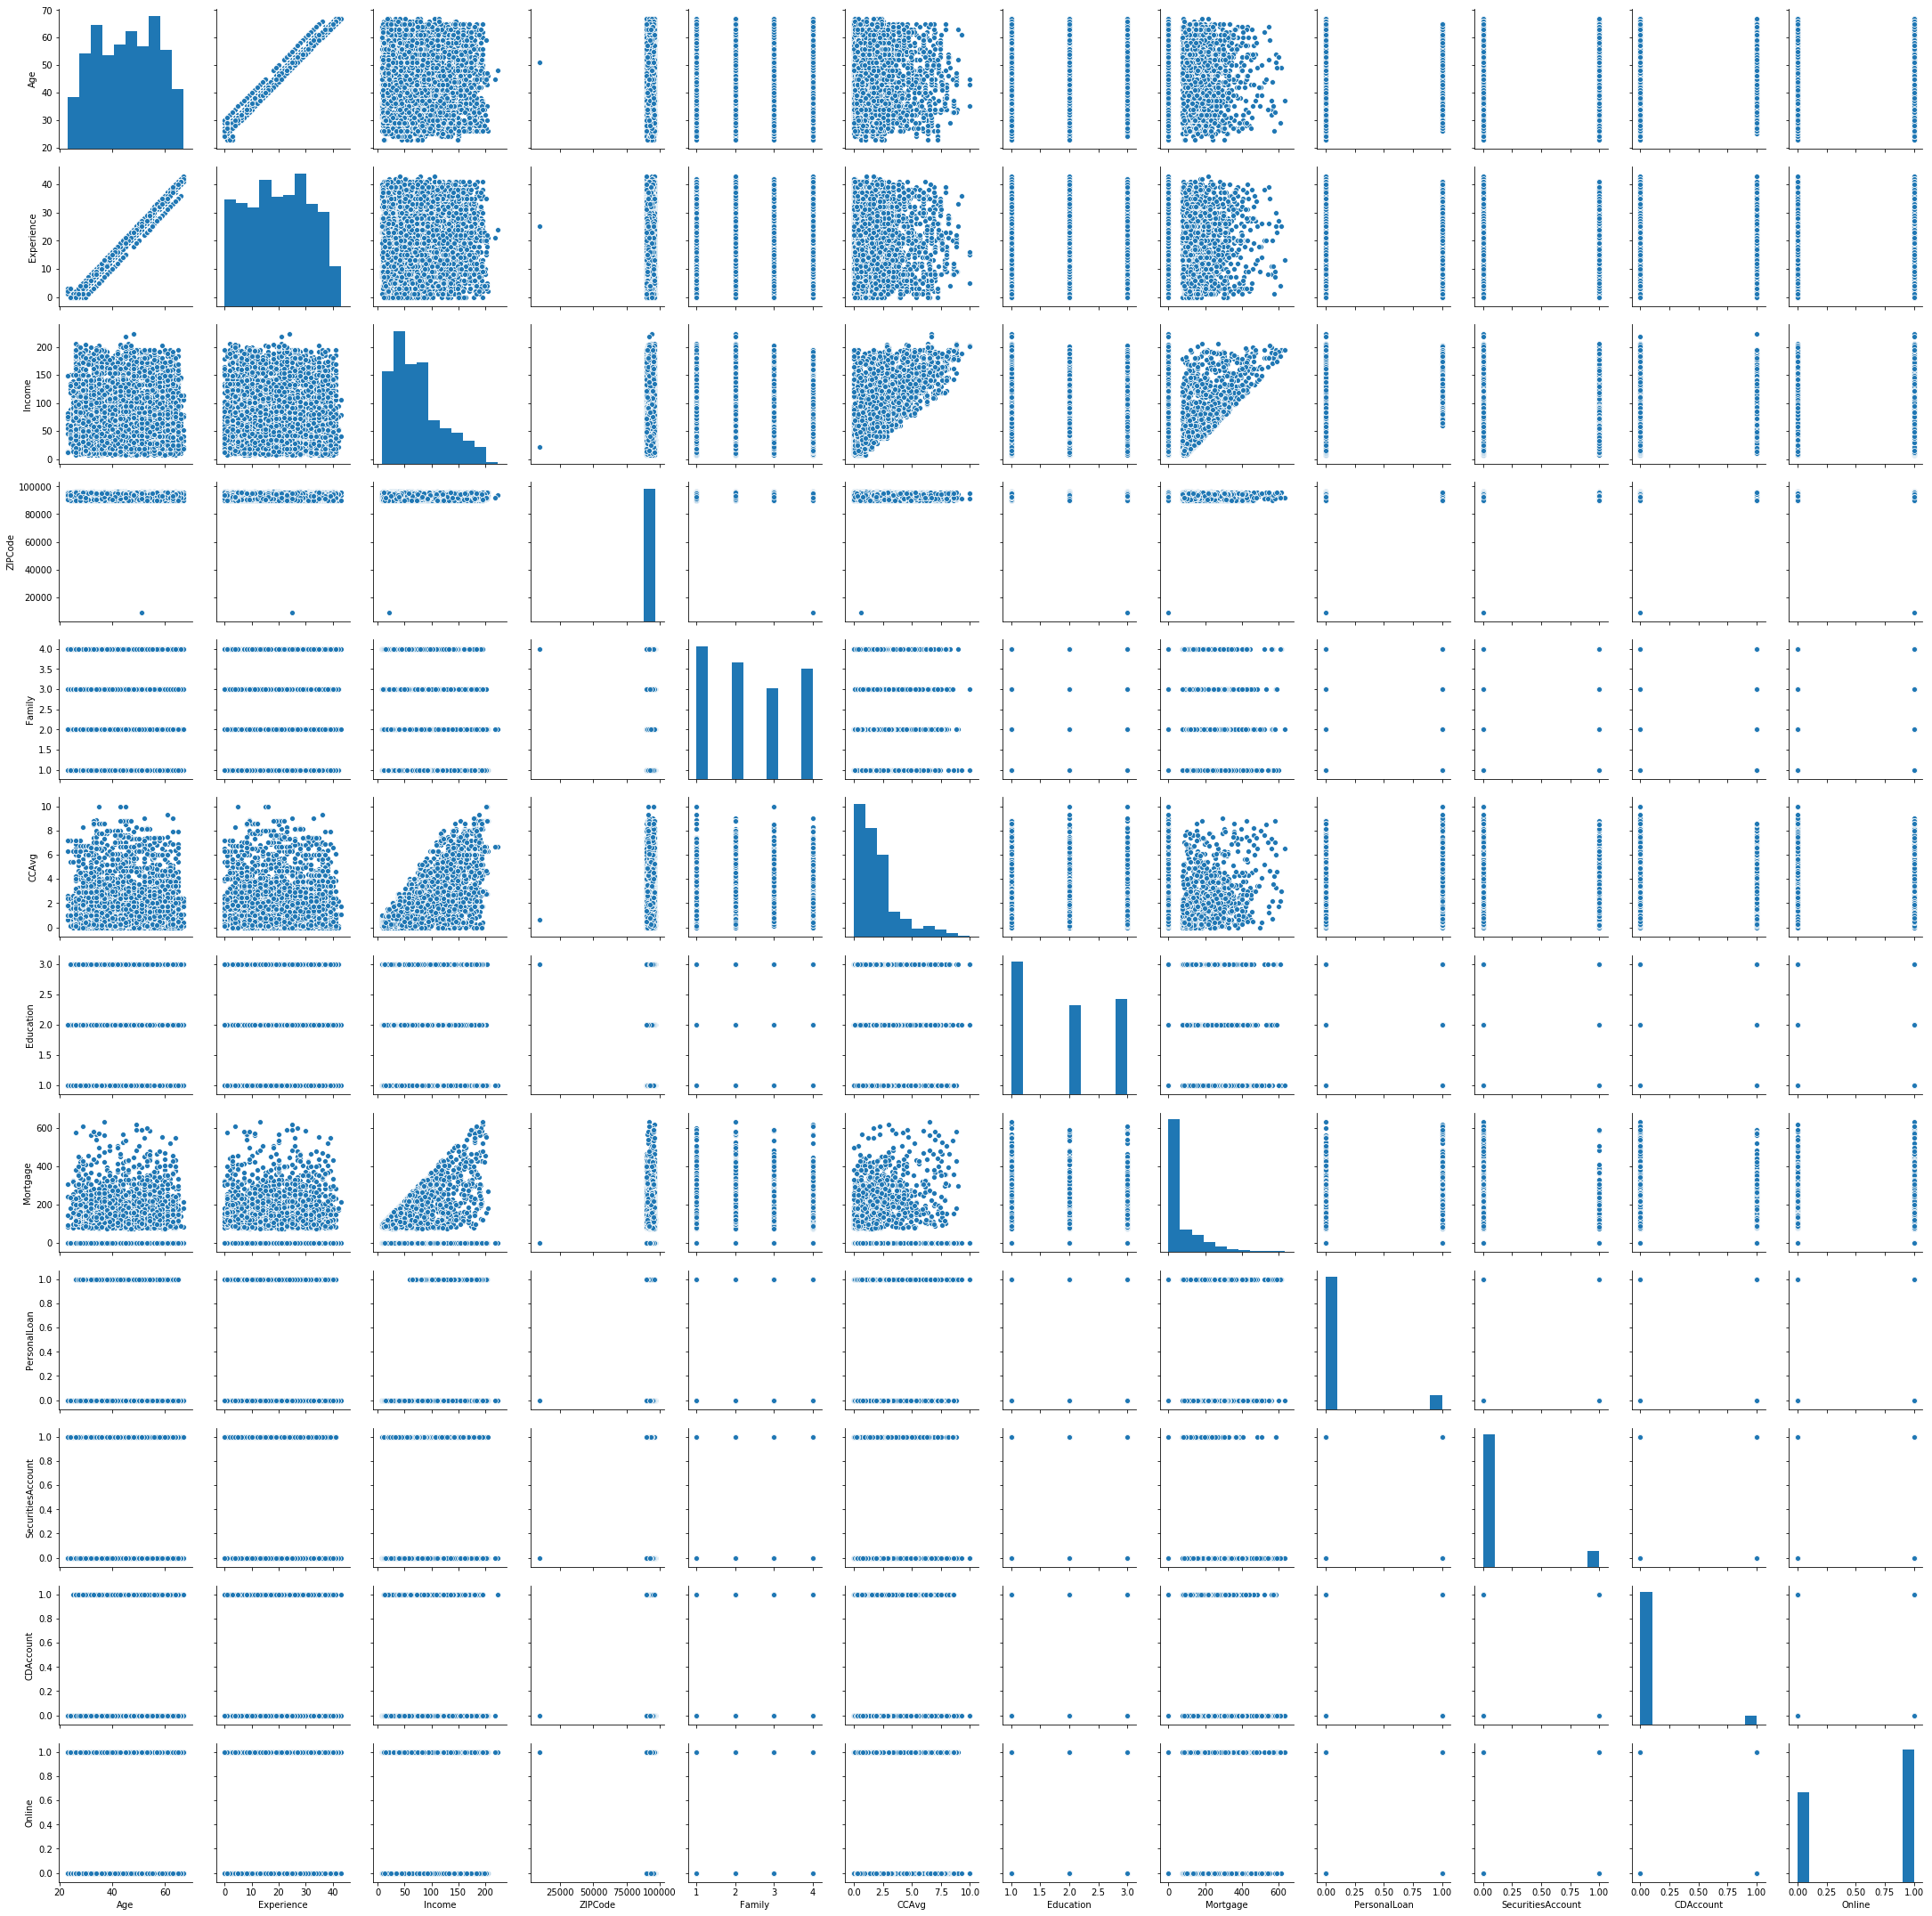

In [6]:
#compare all attributes visually to check for relationships that can be exploited
df_attr = df.iloc[:,0:12] 
sns.pairplot(df_attr)

#Age and experience have strong positive relation
#Age and income have no linear relationship

In [7]:
# Drop the Experiance as it is strongly corelated to Age
df.drop('Experience',axis =1,inplace=True)

In [8]:
familysize_no = np.mean( df[df.PersonalLoan == 0]['Family'] )
familysize_yes = np.mean( df[df.PersonalLoan == 1]['Family'] )
stats.ttest_ind(df[df.PersonalLoan == 1]['Family'], df[df.PersonalLoan == 1]['Family'])

Ttest_indResult(statistic=0.0, pvalue=1.0)

Observation: Family size seems to have no impact on decision to take a loan.

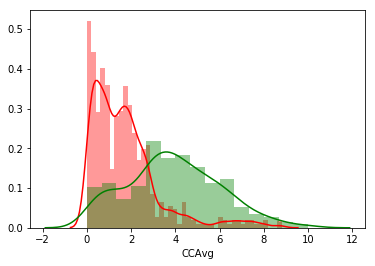

In [9]:
sns.distplot( df[df.PersonalLoan == 0]['CCAvg'], color = 'r')
sns.distplot( df[df.PersonalLoan == 1]['CCAvg'], color = 'g')

Observation: Customers who have taken personal loan have higher credit card average than those who did nottake. So high credit card average seems to be good predictor of whether or not a customer will take a personal loan.

# Get the target column distribution. Your comments (5 points)

In [10]:
df.groupby(["PersonalLoan"]).count()

,Age,Income,ZIPCode,Family,CCAvg,Education,Mortgage,SecuritiesAccount,CDAccount,Online,CreditCard
PersonalLoan,,,,,,,,,,,
0,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520
1,480,480,480,480,480,480,480,480,480,480,480


#The data set is skewed in terms of target column.
#There are far few records in class 1 i.e. people who took the personal loan last time. 
#But that is the class of interst to us! We have to identify potential customers and do not want any potential customer to be missed. 

# Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)

In [11]:
X = df.drop("PersonalLoan", axis=1)
y = df["PersonalLoan"]
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
print(df.shape)
print(X_train.shape)
print(X_test.shape)

(5000, 12)
(3500, 11)
(1500, 11)


# Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)

## Logistic Regression Model

In [12]:
model = LogisticRegression()
model.fit(X_train, y_train)
LRmodel_score = model.score(X_test, y_test)
LRy_predict = model.predict(X_test)
print(LRmodel_score)
print(metrics.classification_report(y_test, LRy_predict))

0.9186666666666666
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      1362
           1       0.62      0.30      0.41       138

   micro avg       0.92      0.92      0.92      1500
   macro avg       0.78      0.64      0.68      1500
weighted avg       0.90      0.92      0.91      1500



## K Nearest Neighbour Model

In [13]:
NNH = KNeighborsClassifier(n_neighbors= 3 , weights = 'distance')
NNH.fit(X_train, y_train)
Knnmodel_score = NNH.score(X_test, y_test)
KNNy_predict = NNH.predict(X_test)
print(Knnmodel_score)
print(metrics.classification_report(y_test, KNNy_predict))

0.8986666666666666
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1362
           1       0.42      0.25      0.32       138

   micro avg       0.90      0.90      0.90      1500
   macro avg       0.67      0.61      0.63      1500
weighted avg       0.88      0.90      0.89      1500



## Naive Bayes Model

In [14]:
NBmodel = GaussianNB()
NBmodel.fit(X_train, y_train)
NBmodel_score = NBmodel.score(X_test, y_test)
NBy_predict = NBmodel.predict(X_test)
print(NBmodel_score)
print(metrics.classification_report(y_test, NBy_predict))

0.88
              precision    recall  f1-score   support

           0       0.96      0.91      0.93      1362
           1       0.40      0.59      0.48       138

   micro avg       0.88      0.88      0.88      1500
   macro avg       0.68      0.75      0.70      1500
weighted avg       0.91      0.88      0.89      1500



# Print the confusion matrix for all the above models (10 points)

## Confusion Matrix for Logistic Regression model

In [15]:
print(metrics.confusion_matrix(y_test, LRy_predict))

[[1336   26]
 [  96   42]]


## Confusion Matrix for K Nearest Neighbour Model

In [16]:
print(metrics.confusion_matrix(y_test, KNNy_predict))

[[1313   49]
 [ 103   35]]


## Confusion Matrix for Naive Bayes Model

In [17]:
print(metrics.confusion_matrix(y_test, NBy_predict))

[[1238  124]
 [  56   82]]


# Give your reasoning on which is the best model in this case and why it performs better? (10 points)

Precision: Within a given set of positively-labeled results, the fraction that were 
True positives = tp/(tp + fp) , this has to be calculated for each class i.e. 0 and 1 and should be high for the class less represented, class 1 in our example

Recall: Given a set of positively-labeled results, the fraction of all positives that were retrieved = tp/(tp + fn)

Accuracy: tp + tn / (tp + tn + fp +fn) But this measure can be dominated by larger class. 
Suppose 10, 90 and 80 of 90 is correctly predicted while only 2 of 0 is predicted correctly. 
Accuracy is 80+2 / 100 i.e. 82%

F is harmonic mean of precision and recal given by ((B^2 +1) PR) / (B^2P +R)
When B is set to 1 we get F1 = 2PR / (P+R)

Regression Model
The precision and recall for class 1 is low in Logistic Regression Model

KNN Model
Recall (true positives / (true positives + false negatives)) for class 1 is the least. That is because majority of data points belong to class 0 and in KNN, probability of finding data points from class 0 closer to a test point than a data point from class 1 is high.

Naive Bayes
Naive Bayes is not giving the class 1 metrics in the acceptal range (80% and above)